In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [9]:
df_index=pd.read_csv("multiple.csv")

In [10]:
df_index.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2024,1,3.50,6.10,1465
1,2024,2,3.55,6.05,1472
2,2024,3,3.60,5.98,1484
3,2024,4,3.65,5.92,1491
4,2024,5,3.70,5.88,1503


In [11]:
## drop unnecessay column

df_index.drop(columns=["year", "month"], inplace=True)

In [12]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,3.50,6.10,1465
1,3.55,6.05,1472
2,3.60,5.98,1484
3,3.65,5.92,1491
4,3.70,5.88,1503


In [13]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

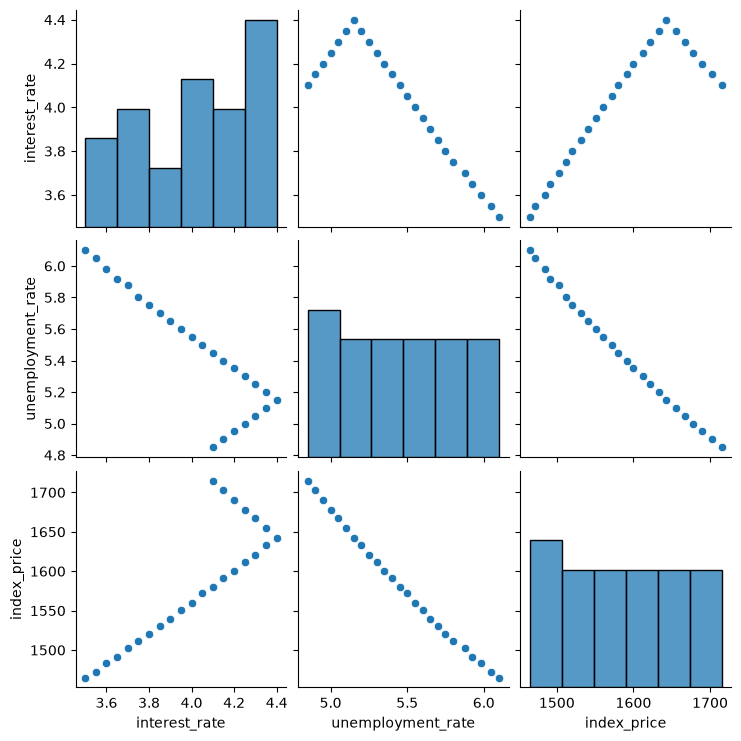

In [14]:
import seaborn as sns
sns.pairplot(df_index)

In [15]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.897779,0.873076
unemployment_rate,-0.897779,1.000000,-0.997775
index_price,0.873076,-0.997775,1.000000


Text(0, 0.5, 'unemployement_rate')

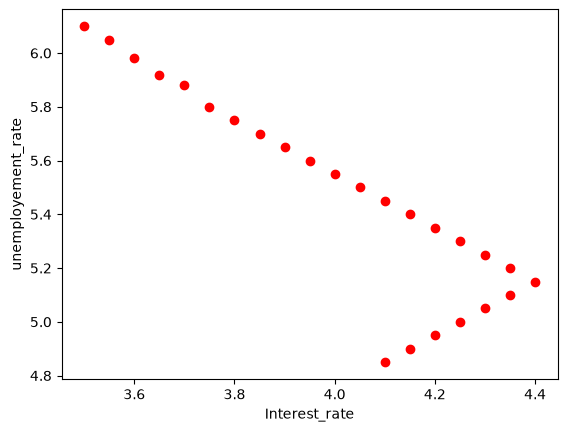

In [18]:
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel("Interest_rate")
plt.ylabel("unemployement_rate")

In [24]:
## X=df_index[['interest_rate','unemployement_rate']]  or use ilock
x=df_index.iloc[:,:-1]
y=df_index.iloc[:,-1]

In [38]:
## train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [39]:
import seaborn as sns

<Axes: xlabel='interest_rate', ylabel='index_price'>

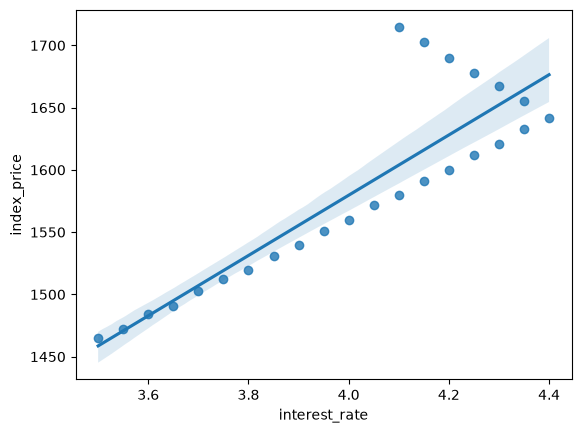

In [40]:
sns.regplot(x='interest_rate', y='index_price', data=df_index)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

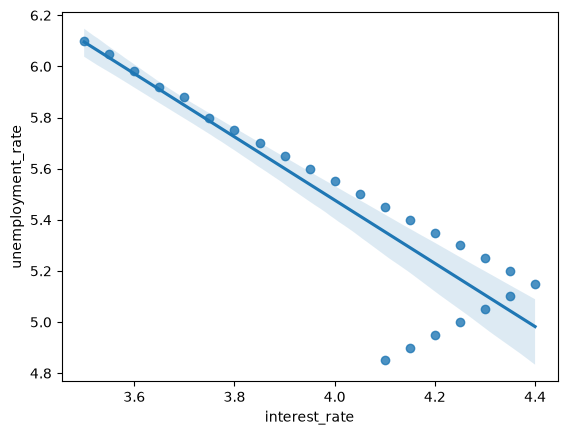

In [41]:
sns.regplot(x='interest_rate', y='unemployment_rate', data=df_index)

In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [44]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ -8.11,-84.08]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1586
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[5.86,1.3 ]"


In [51]:
from sklearn.model_selection import cross_val_score
val_score = cross_val_score(regression, x_train, y_train, scoring='neg_mean_squared_error',cv=5)
np.mean(val_score)

np.float64(-14.745832670947035)

In [62]:
## predictiion
y_pred=regression.predict(x_test)
y_pred

array([1544.36812081, 1621.07339934, 1456.62560442, 1702.68129862,
       1573.13260026, 1553.95628063, 1592.30891989])

In [54]:
##performance
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [56]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

14.436226951179586
2.647488272335912
3.7995035137738173


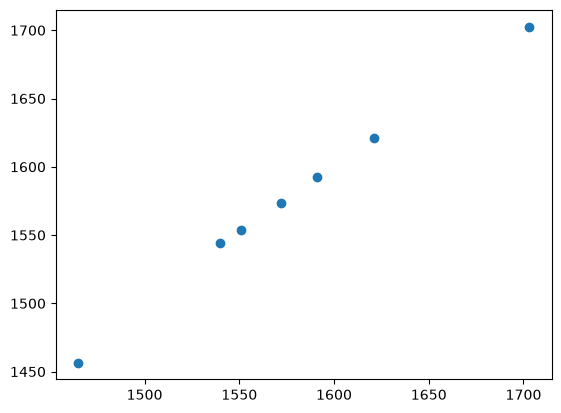

In [57]:
##assumptions

plt.scatter(y_test,y_pred)

In [58]:
residuals=y_test-y_pred
print(residuals)

8    -4.368121
16   -0.073399
0     8.374396
23    0.318701
11   -1.132600
9    -2.956281
13   -1.308920
Name: index_price, dtype: float64


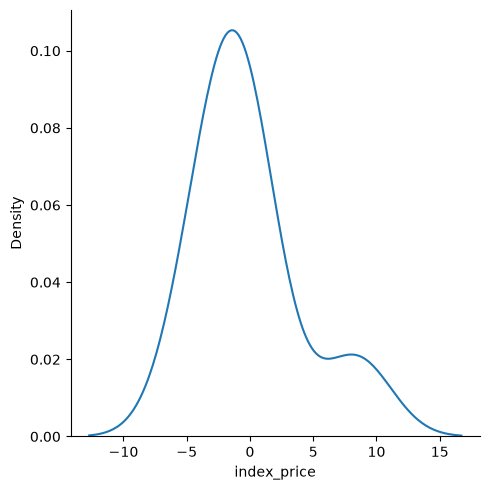

In [59]:
sns.displot(residuals,kind='kde')

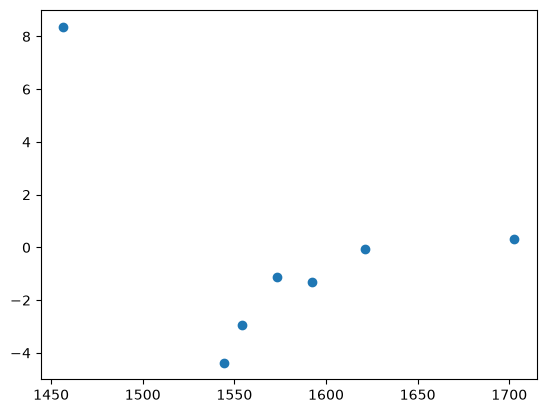

In [60]:
plt.scatter(y_pred,residuals)

In [ ]:
## data is not uniformly distributed so something is wrong ..... as it is following a pattern

In [61]:
print(regression.coef_)

[ -8.11458154 -84.08008756]
